# Grid search CV

In [12]:
import pandas as pd
import seaborn as sns


In [13]:
df = pd.read_csv("cancer_clf.csv")

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

X = df.drop("target_var", axis = 1)
y = df["target_var"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)
scaler = StandardScaler()
clf = LogisticRegression()
pipe = make_pipeline(scaler, clf)

param_grid = {
    "logisticregression__C": [.01, .1, 1, 1.5, 2]
}

grid = GridSearchCV(pipe,param_grid=param_grid,scoring="recall")

grid.fit(X_train,y_train)

print(f"Best score:{grid.best_score_}\nBest params: {grid.best_params_}")


Best score:0.9960000000000001
Best params: {'logisticregression__C': 0.01}


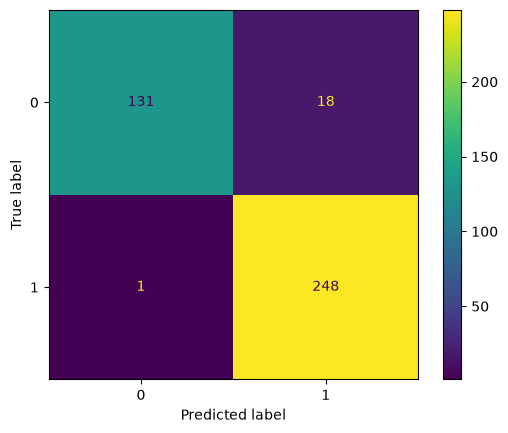

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train)

0.9748101265822784
{'logisticregression__C': 1}


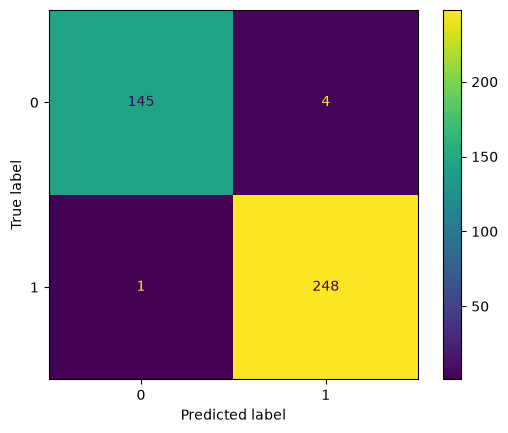

In [16]:
grid = GridSearchCV(pipe, param_grid, scoring='accuracy')

grid.fit(X_train, y_train)

print(f"{grid.best_score_ }\n{grid.best_params_}")

ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train)

Precision: 0.9323308270676691
Recall: 0.9959839357429718
Accuracy: 0.9522613065326633
F1: 0.9631067961165048
Classification Report:               precision    recall  f1-score   support

           0       0.99      0.88      0.93       149
           1       0.93      1.00      0.96       249

    accuracy                           0.95       398
   macro avg       0.96      0.94      0.95       398
weighted avg       0.95      0.95      0.95       398



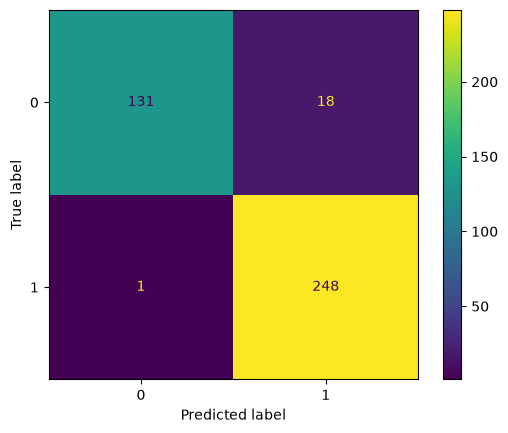

In [17]:
from sklearn.metrics import f1_score, classification_report, recall_score, accuracy_score, precision_score

grid = GridSearchCV(pipe, param_grid, scoring='recall') # Most common to optimize for recall in medical diagnosis

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_train)

precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
accuracy = accuracy_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)
classification_rep = classification_report(y_train, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")
print(f"F1: {f1}")
print(f"Classification Report: {classification_rep}")

ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train)

Precision: 0.9391304347826087
Recall: 1.0
Accuracy: 0.9590643274853801
F1: 0.968609865470852
Classification Report:               precision    recall  f1-score   support

           0       1.00      0.89      0.94        63
           1       0.94      1.00      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.96      0.96       171



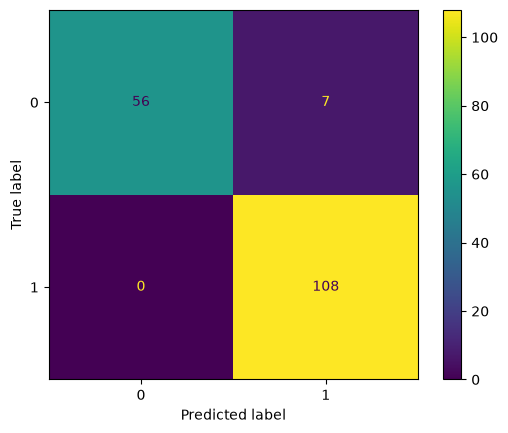

In [18]:
from sklearn.metrics import f1_score, classification_report, recall_score, accuracy_score, precision_score

grid = GridSearchCV(pipe, param_grid, scoring='recall') # Most common to optimize for recall in medical diagnosis

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")
print(f"F1: {f1}")
print(f"Classification Report: {classification_rep}")

ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test)